In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support
import warnings

In [2]:
a1=pd.read_excel('D:\ml\credit_risk_modeling\case_study1.xlsx')
a2=pd.read_excel('D:\ml\credit_risk_modeling\case_study2.xlsx')

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Soumya\AppData\Local\Temp\ipykernel_16804\1968807503.py:1: SyntaxWarning: invalid escape sequence '\m'
  a1=pd.read_excel('D:\ml\credit_risk_modeling\case_study1.xlsx')
C:\Users\Soumya\AppData\Local\Temp\ipykernel_16804\1968807503.py:2: SyntaxWarning: invalid escape sequence '\m'
  a2=pd.read_excel('D:\ml\credit_risk_modeling\case_study2.xlsx')


In [3]:
df1=a1.copy()
df2=a2.copy()

In [4]:
print(a1.shape)
print(a2.shape)

(51336, 26)
(51336, 62)


In [5]:
#Removing null from df1
df1=df1.loc[df1['Age_Oldest_TL']!=-99999]

In [6]:
#Removing columns which have more then 10k(20%) null values
columns_removed=[]
for i in df2.columns:
    if  df2.loc[df2[i]==-99999].shape[0]>10000:
        columns_removed.append(i)

print(f'columns to be removed :{columns_removed}')
df2=df2.drop(columns_removed,axis=1)

columns to be removed :['time_since_first_deliquency', 'time_since_recent_deliquency', 'max_delinquency_level', 'max_deliq_6mts', 'max_deliq_12mts', 'CC_utilization', 'PL_utilization', 'max_unsec_exposure_inPct']


In [7]:
df2.shape

(51336, 54)

In [8]:
#Removing rows contaning null values 
for i in df2.columns:
    df2 = df2.loc[ df2[i] != -99999 ]

In [9]:
df2.shape

(42066, 54)

In [10]:
#Merging the datasets:

#Checking for the comman col
for i in list(df1.columns):
    if i in list(df2.columns):
        print(i)

df=pd.merge(df1,df2,how='inner',left_on=['PROSPECTID'],right_on=['PROSPECTID'])


PROSPECTID


In [11]:
# this is our final merged dataset
df.shape

(42064, 79)

In [12]:
# checking for categorical columns
cat_col=[]
for i in df.columns:
    if df[i].dtype=='object':
        cat_col.append(i)

In [13]:
print(cat_col)

['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2', 'Approved_Flag']


In [14]:
#Performing chi-sq test on cat_col
for i in cat_col:
    chi2, pval, _, _=chi2_contingency(pd.crosstab(df[i],df['Approved_Flag']))
    print(i, '---', pval)

MARITALSTATUS --- 3.578180861038862e-233
EDUCATION --- 2.6942265249737532e-30
GENDER --- 1.907936100186563e-05
last_prod_enq2 --- 0.0
first_prod_enq2 --- 7.84997610555419e-287
Approved_Flag --- 0.0


In [15]:
# Since all the categorical features have pval <=0.05, we will accept all

In [16]:
df.shape

(42064, 79)

In [17]:
#Numerical columns
numeric_columns = []
for i in df.columns:
    if df[i].dtype != 'object':
        numeric_columns.append(i)

In [18]:
# check Anova for columns_to_be_kept 

from scipy.stats import f_oneway

columns_to_be_kept_numerical = []

for i in numeric_columns:
    a = list(df[i])  
    b = list(df['Approved_Flag'])  
    
    group_P1 = [value for value, group in zip(a, b) if group == 'P1']
    group_P2 = [value for value, group in zip(a, b) if group == 'P2']
    group_P3 = [value for value, group in zip(a, b) if group == 'P3']
    group_P4 = [value for value, group in zip(a, b) if group == 'P4']


    f_statistic, p_value = f_oneway(group_P1, group_P2, group_P3, group_P4)

    if p_value <= 0.05:
        columns_to_be_kept_numerical.append(i)

In [19]:
len(columns_to_be_kept_numerical)

70

In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = df[columns_to_be_kept_numerical].copy()

columns_to_be_kept = []

column_index = 0

while column_index < vif_data.shape[1]:

    vif_value = variance_inflation_factor(vif_data.values, column_index)

    column_name = vif_data.columns[column_index]

    print(column_name, "---", vif_value)

    if vif_value <= 5:
        columns_to_be_kept.append(column_name)
        column_index += 1

    else:
        vif_data = vif_data.drop(columns=[column_name])




C:\Users\Soumya\AppData\Local\Temp\ipykernel_16804\1726939809.py:11: UserWarning: The design matrix is poorly conditioned (condition number=2.57e+16). VIF calculations may be numerically unstable.
  vif_value = variance_inflation_factor(vif_data.values, column_index)
C:\Users\Soumya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


PROSPECTID --- 1.00126776425783


C:\Users\Soumya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


Total_TL --- 1000799917193443.5


C:\Users\Soumya\AppData\Local\Temp\ipykernel_16804\1726939809.py:11: UserWarning: The design matrix is poorly conditioned (condition number=2.91e+16). VIF calculations may be numerically unstable.
  vif_value = variance_inflation_factor(vif_data.values, column_index)
C:\Users\Soumya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


Tot_Closed_TL --- 1000799917193443.5


C:\Users\Soumya\AppData\Local\Temp\ipykernel_16804\1726939809.py:11: UserWarning: The design matrix is poorly conditioned (condition number=2.97e+16). VIF calculations may be numerically unstable.
  vif_value = variance_inflation_factor(vif_data.values, column_index)
C:\Users\Soumya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


Tot_Active_TL --- 11.320443267587782


C:\Users\Soumya\AppData\Local\Temp\ipykernel_16804\1726939809.py:11: UserWarning: The design matrix is poorly conditioned (condition number=3.21e+16). VIF calculations may be numerically unstable.
  vif_value = variance_inflation_factor(vif_data.values, column_index)
C:\Users\Soumya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
C:\Users\Soumya\AppData\Local\Temp\ipykernel_16804\1726939809.py:11: UserWarning: The design matrix is poorly conditioned (condition number=2.99e+16). VIF calculations may be numerically unstable.
  vif_value = variance_inflation_factor(vif_data.values, column_index)


Total_TL_opened_L6M --- 8.363968148795148


C:\Users\Soumya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
C:\Users\Soumya\AppData\Local\Temp\ipykernel_16804\1726939809.py:11: UserWarning: The design matrix is poorly conditioned (condition number=2.59e+16). VIF calculations may be numerically unstable.
  vif_value = variance_inflation_factor(vif_data.values, column_index)


Tot_TL_closed_L6M --- 6.520617458564012


C:\Users\Soumya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


pct_tl_open_L6M --- 5.149760520179805


C:\Users\Soumya\AppData\Local\Temp\ipykernel_16804\1726939809.py:11: UserWarning: The design matrix is poorly conditioned (condition number=2.76e+16). VIF calculations may be numerically unstable.
  vif_value = variance_inflation_factor(vif_data.values, column_index)
C:\Users\Soumya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


pct_tl_closed_L6M --- 2.609861594961563


C:\Users\Soumya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
C:\Users\Soumya\AppData\Local\Temp\ipykernel_16804\1726939809.py:11: UserWarning: The design matrix is poorly conditioned (condition number=6.78e+15). VIF calculations may be numerically unstable.
  vif_value = variance_inflation_factor(vif_data.values, column_index)


pct_active_tl --- 1000799917193443.5


C:\Users\Soumya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
C:\Users\Soumya\AppData\Local\Temp\ipykernel_16804\1726939809.py:11: UserWarning: The design matrix is poorly conditioned (condition number=4.41e+15). VIF calculations may be numerically unstable.
  vif_value = variance_inflation_factor(vif_data.values, column_index)


pct_closed_tl --- 1000799917193443.5


C:\Users\Soumya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
C:\Users\Soumya\AppData\Local\Temp\ipykernel_16804\1726939809.py:11: UserWarning: The design matrix is poorly conditioned (condition number=3.27e+15). VIF calculations may be numerically unstable.
  vif_value = variance_inflation_factor(vif_data.values, column_index)


Total_TL_opened_L12M --- 5.524822301012357


C:\Users\Soumya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


Tot_TL_closed_L12M --- 2.9748129886806085


C:\Users\Soumya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


pct_tl_open_L12M --- 2.42622706855634


C:\Users\Soumya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


pct_tl_closed_L12M --- 4.034431823600916


C:\Users\Soumya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


Tot_Missed_Pmnt --- 1.618488497873002


C:\Users\Soumya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


Auto_TL --- 1000799917193443.5


C:\Users\Soumya\AppData\Local\Temp\ipykernel_16804\1726939809.py:11: UserWarning: The design matrix is poorly conditioned (condition number=3.04e+15). VIF calculations may be numerically unstable.
  vif_value = variance_inflation_factor(vif_data.values, column_index)
C:\Users\Soumya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


CC_TL --- 4.495860693606266


C:\Users\Soumya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


Consumer_TL --- 17.598042330324745


C:\Users\Soumya\AppData\Local\Temp\ipykernel_16804\1726939809.py:11: UserWarning: The design matrix is poorly conditioned (condition number=4.55e+15). VIF calculations may be numerically unstable.
  vif_value = variance_inflation_factor(vif_data.values, column_index)
C:\Users\Soumya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


Gold_TL --- 28.317803119124868


C:\Users\Soumya\AppData\Local\Temp\ipykernel_16804\1726939809.py:11: UserWarning: The design matrix is poorly conditioned (condition number=3.20e+15). VIF calculations may be numerically unstable.
  vif_value = variance_inflation_factor(vif_data.values, column_index)
C:\Users\Soumya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


Home_TL --- 4.194433780752847


C:\Users\Soumya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


PL_TL --- 2.7167185372757703


C:\Users\Soumya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


Secured_TL --- 2.390990795250254


C:\Users\Soumya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


Unsecured_TL --- 2.9724494705269375


C:\Users\Soumya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


Other_TL --- 1.8375724039367956


C:\Users\Soumya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


Age_Oldest_TL --- 3.7463767615471584


C:\Users\Soumya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


Age_Newest_TL --- 3.7379905223264074


C:\Users\Soumya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


time_since_recent_payment --- 2.709544188810019


C:\Users\Soumya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
C:\Users\Soumya\AppData\Local\Temp\ipykernel_16804\1726939809.py:11: UserWarning: The design matrix is poorly conditioned (condition number=4.03e+15). VIF calculations may be numerically unstable.
  vif_value = variance_inflation_factor(vif_data.values, column_index)


num_times_delinquent --- 6.907677277020753


C:\Users\Soumya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


max_recent_level_of_deliq --- 4.919051968062888
num_deliq_6mts --- 1000799917193443.5
num_deliq_12mts --- 6.6376652381034615
num_deliq_6_12mts --- 1.3116959356634137
num_times_30p_dpd --- 7.619070923997138
num_times_60p_dpd --- 1.5780693663209049
num_std --- 6.156045094152714
num_std_6mts --- 13.167107099211623
num_std_12mts --- 2.1117963833670763
num_sub --- 1.487610695752715
num_sub_6mts --- 2.1674331550363246
num_sub_12mts --- 2.618937776166363
num_dbt --- 2.293832106227564
num_dbt_6mts --- 7.258340152502044
num_dbt_12mts --- 2.1559322633263327
num_lss --- 1.0115727193522557
recent_level_of_deliq --- 4.494891766563055
tot_enq --- 9.650558854663327
CC_enq --- 5.954901720854511
CC_enq_L6m --- 8.426223470279817
CC_enq_L12m --- 2.241998183094311
PL_enq --- 6.937982552220521
PL_enq_L6m --- 11.45965324863232
PL_enq_L12m --- 2.9620642211611905
time_since_recent_enq --- 1.590451213107999
enq_L12m --- 12.09381999622369
enq_L6m --- 7.5903091863508125
enq_L3m --- 3.0577298002060767
AGE --- 1.4

In [22]:
len(columns_to_be_kept)

41

In [23]:
# listing all the final features
features = columns_to_be_kept + ['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2']
df = df[features + ['Approved_Flag']]

In [25]:
df.shape

(42064, 47)

In [26]:
# Label encoding for the categorical features
#['MARITALSTATUS', 'EDUCATION', 'GENDER' , 'last_prod_enq2' ,'first_prod_enq2']

In [27]:
# Ordinal feature -- EDUCATION
# SSC            : 1
# 12TH           : 2
# GRADUATE       : 3
# UNDER GRADUATE : 3
# POST-GRADUATE  : 4
# OTHERS         : 1
# PROFESSIONAL   : 3

In [28]:
df.loc[df['EDUCATION'] == 'SSC',['EDUCATION']] = 1
df.loc[df['EDUCATION']=='12TH',['EDUCATION']]=2
df.loc[df['EDUCATION'] == 'GRADUATE',['EDUCATION']]= 3
df.loc[df['EDUCATION'] == 'UNDER GRADUATE',['EDUCATION']]= 3
df.loc[df['EDUCATION'] == 'POST-GRADUATE',['EDUCATION']]= 4
df.loc[df['EDUCATION'] == 'OTHERS',['EDUCATION']] = 1
df.loc[df['EDUCATION'] == 'PROFESSIONAL',['EDUCATION']]= 3

In [30]:
df['EDUCATION'].value_counts()


EDUCATION
3    18931
2    11703
1     9532
4     1898
Name: count, dtype: int64

In [31]:
#One-hot encoding
df_encoded=pd.get_dummies(df,columns=['MARITALSTATUS', 'EDUCATION', 'GENDER' , 'last_prod_enq2' ,'first_prod_enq2'],dtype=int)
df_encoded.shape

(42064, 62)

In [ ]:
#Machine learning model fitting
#Data processing

In [32]:
#Random forest
y_rf=df_encoded['Approved_Flag']
x_rf=df_encoded.drop(['Approved_Flag'],axis=1)

In [33]:
x_train_rf,x_test_rf,y_train_rf,y_test_rf=train_test_split(x_rf,y_rf,test_size=0.2,random_state=42)

In [34]:
rf_classifier=RandomForestClassifier(n_estimators=200,random_state=42)

In [35]:
rf_classifier.fit(x_train_rf,y_train_rf)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [36]:
y_pred_rf=rf_classifier.predict(x_test_rf)

In [37]:
accuracy = accuracy_score(y_test_rf, y_pred_rf)
print ()
print(f'Accuracy of Random Forest: {accuracy}')
print ()
precision, recall, f1_score, _ = precision_recall_fscore_support(y_test_rf, y_pred_rf)
for i, v in enumerate(['p1', 'p2', 'p3', 'p4']):
    print(f"Class {v}:")
    print(f"Precision: {precision[i]}")
    print(f"Recall: {recall[i]}")
    print(f"F1 Score: {f1_score[i]}")
    print()
    


Accuracy of Random Forest: 0.7634613098775704

Class p1:
Precision: 0.8365384615384616
Recall: 0.6863905325443787
F1 Score: 0.7540628385698809

Class p2:
Precision: 0.7901255230125523
Recall: 0.9357779980178395
F1 Score: 0.8568058076225046

Class p3:
Precision: 0.45454545454545453
Recall: 0.19622641509433963
F1 Score: 0.2741170268845546

Class p4:
Precision: 0.7214700193423598
Recall: 0.7249757045675413
F1 Score: 0.7232186136694134



In [ ]:
#XGBOOST model

In [ ]:
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Separate the target before encoding to prevent target leakage.
target_column = 'Approved_Flag'
X_xgb = df_encoded.drop(columns=[target_column, 'PROSPECTID'], errors='ignore').copy()
y_xgb = df_encoded[target_column].copy()

# Encode predictor columns only.
X_xgb = pd.get_dummies(X_xgb, dtype=int)

le = LabelEncoder()
y_xgb = le.fit_transform(y_xgb)

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb,
    y_xgb,
    test_size=0.2,
    random_state=42,
    stratify=y_xgb
)

xgb_baseline = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='multi:softprob',
    num_class=len(le.classes_),
    eval_metric='mlogloss'
 )

xgb_baseline.fit(X_train_xgb, y_train_xgb)
y_pred_xgb = xgb_baseline.predict(X_test_xgb)

accuracy = accuracy_score(y_test_xgb, y_pred_xgb)
print ()
print(f'Accuracy of Xgboost Forest: {accuracy}')
print ()
precision, recall, f1_score, _ = precision_recall_fscore_support(y_test_xgb, y_pred_xgb)
for i, v in enumerate(['p1', 'p2', 'p3', 'p4']):
    print(f"Class {v}:")
    print(f"Precision: {precision[i]}")
    print(f"Recall: {recall[i]}")
    print(f"F1 Score: {f1_score[i]}")
    print()



Accuracy of Xgboost Forest: 0.7758231308688934

Class p1:
Precision: 0.8295081967213115
Recall: 0.7729124236252546
F1 Score: 0.8002108592514496

Class p2:
Precision: 0.8206617388243577
Recall: 0.9161100196463654
F1 Score: 0.8657630894912737

Class p3:
Precision: 0.42475728155339804
Recall: 0.2717391304347826
F1 Score: 0.3314393939393939

Class p4:
Precision: 0.7610887096774194
Recall: 0.7169990503323836
F1 Score: 0.7383863080684596



In [ ]:
# 3. Decision Tree
from sklearn.tree import DecisionTreeClassifier
y_dt = df_encoded['Approved_Flag']
x_dt = df_encoded. drop ( ['Approved_Flag'], axis = 1 )

x_train_dt, x_test_dt, y_train_dt, y_test_dt = train_test_split(x_dt, y_dt, test_size=0.2, random_state=42)


In [41]:
dt_model = DecisionTreeClassifier(max_depth=20, min_samples_split=10)

In [42]:
dt_model.fit(x_train_dt, y_train_dt)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

In [43]:
y_pred_dt = dt_model.predict(x_test_dt)

In [44]:
accuracy = accuracy_score(y_test_dt, y_pred_dt)
print ()
print(f"Accuracy of Decision Tree: {accuracy:.2f}")
print ()

precision, recall, f1_score, _ = precision_recall_fscore_support(y_test_dt, y_pred_dt)

for i, v in enumerate(['p1', 'p2', 'p3', 'p4']):
    print(f"Class {v}:")
    print(f"Precision: {precision[i]}")
    print(f"Recall: {recall[i]}")
    print(f"F1 Score: {f1_score[i]}")
    print()


Accuracy of Decision Tree: 0.72

Class p1:
Precision: 0.7367367367367368
Recall: 0.7258382642998028
F1 Score: 0.7312468951813215

Class p2:
Precision: 0.8114484625797718
Recall: 0.8317145688800793
F1 Score: 0.8214565387627252

Class p3:
Precision: 0.3661513425549227
Recall: 0.33962264150943394
F1 Score: 0.3523884103367267

Class p4:
Precision: 0.6479289940828402
Recall: 0.6384839650145773
F1 Score: 0.6431718061674009



In [ ]:
#we will select xgboost as our basline model bcz our weakest var p3 improved in xgboost

In [ ]:
#Hyperparameter tuning for xgboost

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Create XGBoost model
xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

# Hyperparameter search space
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3, 0.5],
    'reg_alpha': [0, 0.01, 0.1, 0.5, 1],
    'reg_lambda': [1, 1.5, 2, 5, 10]
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=50,
    scoring='f1_macro',
    cv=5,
    verbose=2,
    random_state=42
)

# Train
random_search.fit(X_train_xgb, y_train_xgb)

# Best parameters
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Accuracy:")
print(random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END colsample_bytree=1.0, gamma=0.5, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=300, reg_alpha=1, reg_lambda=2, subsample=0.6; total time=   3.1s
[CV] END colsample_bytree=1.0, gamma=0.5, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=300, reg_alpha=1, reg_lambda=2, subsample=0.6; total time=   3.2s
[CV] END colsample_bytree=1.0, gamma=0.5, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=300, reg_alpha=1, reg_lambda=2, subsample=0.6; total time=   3.2s
[CV] END colsample_bytree=1.0, gamma=0.5, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=300, reg_alpha=1, reg_lambda=2, subsample=0.6; total time=   4.0s
[CV] END colsample_bytree=1.0, gamma=0.5, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=300, reg_alpha=1, reg_lambda=2, subsample=0.6; total time=   3.6s
[CV] END colsample_bytree=1.0, gamma=0.5, learning_rate=0.15, max_depth=6

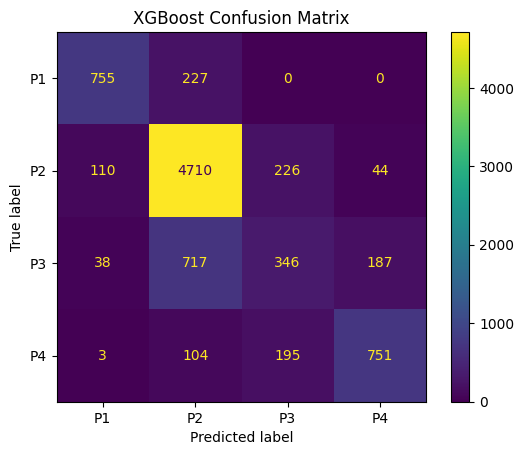

In [ ]:
#confusion matrix shownig 717 P3 are predicted as P2 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_xgb, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

In [ ]:
#Trying class weights for P3 bcz it is difficult to predict
#Bcz the available features do not sufficiently separate P3 from P2

In [95]:
sample_weights = np.ones(len(y_train_xgb))

sample_weights[y_train_xgb == 2] = 2.0

xgb_weighted = XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    
    # Use your best parameters here
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_weighted.fit(
    X_train_xgb,
    y_train_xgb,
    sample_weight=sample_weights
)

y_pred_weighted = xgb_weighted.predict(X_test_xgb)

print("Accuracy:",
      accuracy_score(y_test_xgb, y_pred_weighted))

print(
    classification_report(
        y_test_xgb,
        y_pred_weighted,
        target_names=le.classes_
    )
)

Accuracy: 0.7648876738381077
              precision    recall  f1-score   support

          P1       0.83      0.76      0.79       982
          P2       0.85      0.86      0.86      5090
          P3       0.41      0.51      0.45      1288
          P4       0.84      0.60      0.70      1053

    accuracy                           0.76      8413
   macro avg       0.73      0.68      0.70      8413
weighted avg       0.78      0.76      0.77      8413



In [ ]:
# sacrificed only about 1.5 percentage points of accuracy compared with your 78% model, while almost doubling P3 recall.
#                      Original       P3 Weight 2.0
# Accuracy               78.00%          76.49%
# Macro F1                0.69            0.70
# P3 Recall               27%             51%
# P3 F1                   0.34            0.45

In [ ]:
# Hyperparameter tuning alone could not solve the P3 classification problem, 
# but class weighting substantially improved P3 detection.

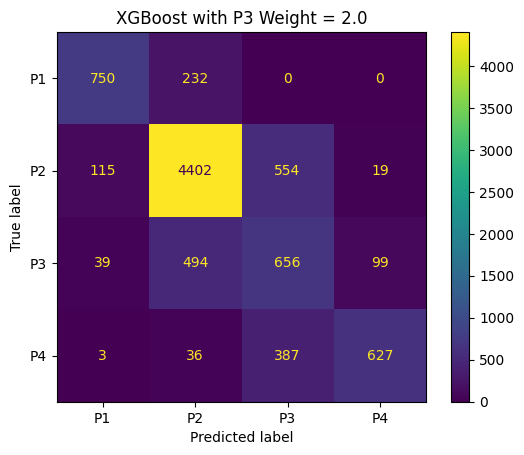

In [62]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_xgb, y_pred_weighted)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot()
plt.title("XGBoost with P3 Weight = 2.0")
plt.show()

In [ ]:
#After class weights confusion matrix less P3 are predicted as P2

In [ ]:
# Why are P2 and P3 so difficult to distinguish?

In [ ]:
#Compare P2 and P3 features
p2_p3 = df[df['Approved_Flag'].isin(['P2', 'P3'])]

p2_p3_summary = p2_p3.groupby('Approved_Flag')[
    columns_to_be_kept
].mean().T

print(p2_p3_summary)

Approved_Flag                         P2            P3
PROSPECTID                  25657.374941  25305.764286
pct_tl_closed_L6M               0.097236      0.112865
Tot_TL_closed_L12M              0.741631      0.766149
pct_tl_open_L12M                0.394310      0.487741
pct_tl_closed_L12M              0.162350      0.173672
Tot_Missed_Pmnt                 0.431243      0.484006
CC_TL                           0.122977      0.135714
Home_TL                         0.056263      0.041615
PL_TL                           0.255422      0.259317
Secured_TL                      2.424878      2.180124
Unsecured_TL                    2.095474      2.288199
Other_TL                        0.919496      0.805435
Age_Oldest_TL                  40.967272     32.527174
Age_Newest_TL                  14.672560     12.141304
time_since_recent_payment     220.383270    182.771118
max_recent_level_of_deliq      10.885903     15.895342
num_deliq_6_12mts               0.275185      0.428416
num_times_

In [64]:
p2_p3_diff = pd.DataFrame({
    'P2_mean': p2_p3_summary['P2'],
    'P3_mean': p2_p3_summary['P3']
})

p2_p3_diff['absolute_difference'] = abs(
    p2_p3_diff['P2_mean'] -
    p2_p3_diff['P3_mean']
)

p2_p3_diff.sort_values(
    'absolute_difference',
    ascending=False
)

,P2_mean,P3_mean,absolute_difference
PROSPECTID,25657.374941,25305.764286,351.610655
NETMONTHLYINCOME,26442.043297,26133.472671,308.570626
time_since_recent_enq,276.785518,127.217702,149.567816
time_since_recent_payment,220.383270,182.771118,37.612152
Time_With_Curr_Empr,110.265598,100.350776,9.914822
Age_Oldest_TL,40.967272,32.527174,8.440098
recent_level_of_deliq,8.712203,13.740528,5.028325
max_recent_level_of_deliq,10.885903,15.895342,5.009439
Age_Newest_TL,14.672560,12.141304,2.531256
AGE,33.507229,32.149534,1.357695


In [ ]:
#Check feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train_xgb.columns,
    'Importance': xgb_weighted.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

print(feature_importance)

                         Feature  Importance
28                       enq_L3m    0.130905
11                 Age_Oldest_TL    0.072288
17                 num_std_12mts    0.059155
36        pct_PL_enq_L6m_of_ever    0.052242
14     max_recent_level_of_deliq    0.049594
27         time_since_recent_enq    0.042574
24         recent_level_of_deliq    0.032973
15             num_deliq_6_12mts    0.018490
2               pct_tl_open_L12M    0.017221
12                 Age_Newest_TL    0.017203
26                   PL_enq_L12m    0.016858
50   last_prod_enq2_ConsumerLoan    0.015347
39                       GL_Flag    0.015231
16             num_times_60p_dpd    0.014966
32        pct_of_active_TLs_ever    0.014667
8                     Secured_TL    0.014305
52             last_prod_enq2_PL    0.013028
13     time_since_recent_payment    0.012862
37        pct_CC_enq_L6m_of_ever    0.011506
34                       CC_Flag    0.011399
10                      Other_TL    0.011277
47        

In [ ]:
# from 5 top feature_importance are :
# enq_L3m → How many times the customer’s credit report was checked/enquired about in the last 3 months.
# Age_Oldest_TL → How old the customer’s oldest credit/loan account is.
# num_std_12mts → Number of certain standard/regular credit accounts or loans in the last 12 months.
# pct_PL_enq_L6m_of_ever → What percentage of the customer’s personal-loan enquiries in the last 6 months are compared with all their enquiries historically.
# Delinquency-related variables → Information about whether the customer has missed or delayed loan/credit payments.

In [ ]:
# The P2/P3 comparison also found that the two groups have noticeably different
# patterns in credit enquiries and payment/delinquency behavior.

# For example:

# A customer making many recent credit enquiries may behave differently from someone making very few.
# A customer with a long credit history may behave differently from someone with a very short history.
# A customer who has missed payments may have a different risk profile from someone who always pays on time.

# “The analysis shows that recent credit enquiries, length of credit history, recent credit activity and missed-payment history 
# are some of the most important factors for distinguishing between the groups.”

In [ ]:
#Handiling useen data col mismatch and encoding problem

In [ ]:

# Use the best estimator selected by RandomizedSearchCV.
best_xgb = random_search.best_estimator_

# Load the raw unseen data and apply the same preprocessing as training.
unseen_df = pd.read_excel(r'D:\ml\credit_risk_modeling\Unseen_Dataset.xlsx')

education_mapping = {
    'SSC': 1,
    '12TH': 2,
    'GRADUATE': 3,
    'UNDER GRADUATE': 3,
    'POST-GRADUATE': 4,
    'OTHERS': 1,
    'PROFESSIONAL': 3
}

unseen_prepared = unseen_df.copy()
unseen_prepared['EDUCATION'] = unseen_prepared['EDUCATION'].map(education_mapping)

unseen_encoded = pd.get_dummies(
    unseen_prepared,
    columns=[
        'MARITALSTATUS',
        'EDUCATION',
        'GENDER',
        'last_prod_enq2',
        'first_prod_enq2'
    ],
    dtype=int
)

# Use the exact feature names and order used to train XGBoost.
trained_columns = X_train_xgb.columns.tolist()
missing_columns = [col for col in trained_columns if col not in unseen_encoded.columns]
extra_columns = [col for col in unseen_encoded.columns if col not in trained_columns]

X_unseen = unseen_encoded.reindex(columns=trained_columns, fill_value=0)

print('Missing training columns filled with 0:', missing_columns)
print('Extra unseen columns ignored:', extra_columns)
print('Training shape:', X_train_xgb.shape)
print('Unseen shape:', X_unseen.shape)
print('Columns match:', list(X_unseen.columns) == trained_columns)

# Predict with the tuned model and decode the class numbers.
predictions_encoded = best_xgb.predict(X_unseen).astype(int)
predicted_labels = le.inverse_transform(predictions_encoded)

unseen_df['Predicted_Approved_Flag'] = predicted_labels

print('\nPrediction distribution:')
print(unseen_df['Predicted_Approved_Flag'].value_counts())

unseen_df.to_excel('unseen_data_predictions.xlsx', index=False)
print('\nPredictions saved to: unseen_data_predictions.xlsx')

Missing training columns filled with 0: ['pct_tl_open_L12M', 'AGE', 'pct_of_active_TLs_ever', 'pct_opened_TLs_L6m_of_L12m']
Extra unseen columns ignored: ['pct_tl_open_L6M']
Training shape: (33651, 60)
Unseen shape: (100, 60)
Columns match: True

Prediction distribution:
Predicted_Approved_Flag
P2    72
P4    14
P1     7
P3     7
Name: count, dtype: int64

Predictions saved to: unseen_data_predictions.xlsx


In [93]:
df['Approved_Flag'].value_counts()

Approved_Flag
P2    25452
P3     6440
P4     5264
P1     4908
Name: count, dtype: int64

In [94]:
# Compare class percentages: predictions versus the original labeled dataset.
original_percent = (
    df['Approved_Flag']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Original_Percentage')
)

predicted_percent = (
    unseen_df['Predicted_Approved_Flag']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Predicted_Percentage')
)

comparison = pd.concat([original_percent, predicted_percent], axis=1).fillna(0)
comparison['Difference_Percentage_Points'] = (
    comparison['Predicted_Percentage'] - comparison['Original_Percentage']
)

comparison = comparison.reindex(le.classes_).fillna(0)

print('Class percentage comparison:')
print(comparison.round(2))

print('\nOriginal class percentages:')
print(original_percent.reindex(le.classes_).fillna(0).round(2))

print('\nPredicted class percentages:')
print(predicted_percent.reindex(le.classes_).fillna(0).round(2))

Class percentage comparison:
    Original_Percentage  Predicted_Percentage  Difference_Percentage_Points
P1                11.67                   7.0                         -4.67
P2                60.51                  72.0                         11.49
P3                15.31                   7.0                         -8.31
P4                12.51                  14.0                          1.49

Original class percentages:
Approved_Flag
P1    11.67
P2    60.51
P3    15.31
P4    12.51
Name: Original_Percentage, dtype: float64

Predicted class percentages:
Predicted_Approved_Flag
P1     7.0
P2    72.0
P3     7.0
P4    14.0
Name: Predicted_Percentage, dtype: float64
